# Лабораторная работа: математический анализ и матричное исчисление

**Студент:** Тоц Леонид Александрович  
**Группа:** ИВТ-2  
**Год:** 2026

В работе последовательно рассмотрены суммы по индексам, производные, дифференциалы, градиенты, производные по направлению, якобианы, JVP/VJP, гессианы, матричные градиенты и численная оптимизация. Все аналитические результаты сопровождаются вычислительной проверкой.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

X_data = np.array([
    [1, 0, -1],
    [0, 1, 1],
    [1, 1, 0],
    [-1, 2, 1],
], dtype=float)

Y_data = np.array([
    [0.2, 0.8],
    [0.7, 0.1],
    [0.6, 0.4],
    [0.1, 0.9],
], dtype=float)

W_initial = np.array([
    [0.2, -0.3],
    [0.4, 0.1],
    [-0.5, 0.2],
], dtype=float)

b_initial = np.array([0.1, -0.2], dtype=float)
regularization = 0.05

def sigmoid(z):
    z_safe = np.clip(z, -50.0, 50.0)
    return 1.0 / (1.0 + np.exp(-z_safe))

print("X:", X_data.shape, "Y:", Y_data.shape)
print("W:", W_initial.shape, "b:", b_initial.shape)
print("lambda =", regularization)


X: (4, 3) Y: (4, 2)
W: (3, 2) b: (2,)
lambda = 0.05


## 1. Суммы, индексы и матричная запись

### 1.1. От суммы к матрице

Дано:
$$
A=\begin{pmatrix}1&2&-1\\0&3&1\end{pmatrix},\qquad
B=\begin{pmatrix}2&1\\1&-1\\0&2\end{pmatrix}.
$$

Размерности:
$$
A\in\mathbb R^{2\times3},\quad B\in\mathbb R^{3\times2},\quad
C=AB\in\mathbb R^{2\times2}.
$$

Индексная запись:
$$
C_{ij}=\sum_{k=1}^{3}A_{ik}B_{kj}.
$$
Здесь $i,j$ — свободные индексы, а $k$ — суммируемый индекс. Поэтому $k$ исчезает после суммирования, а перестановка индексов $j$ и $k$ изменила бы смысл выражения и нарушила согласование размерностей.

Ручное вычисление:
$$
C_{11}=1\cdot2+2\cdot1+(-1)\cdot0=4,
$$
$$
C_{12}=1\cdot1+2\cdot(-1)+(-1)\cdot2=-3,
$$
$$
C_{21}=0\cdot2+3\cdot1+1\cdot0=3,
$$
$$
C_{22}=0\cdot1+3\cdot(-1)+1\cdot2=-1.
$$

Следовательно,
$$
C=\begin{pmatrix}4&-3\\3&-1\end{pmatrix}.
$$


In [2]:
A = np.array([[1, 2, -1], [0, 3, 1]], dtype=float)
B = np.array([[2, 1], [1, -1], [0, 2]], dtype=float)

C_manual = np.array([[4, -3], [3, -1]], dtype=float)
C_matmul = A @ B

C_loops = np.zeros((A.shape[0], B.shape[1]))
for i in range(A.shape[0]):
    for j in range(B.shape[1]):
        for k in range(A.shape[1]):
            C_loops[i, j] += A[i, k] * B[k, j]

print("C вручную:\n", C_manual)
print("C через @:\n", C_matmul)
print("C через циклы:\n", C_loops)
print("Совпадение:", np.allclose(C_manual, C_matmul) and np.allclose(C_manual, C_loops))


C вручную:
 [[ 4. -3.]
 [ 3. -1.]]
C через @:
 [[ 4. -3.]
 [ 3. -1.]]
C через циклы:
 [[ 4. -3.]
 [ 3. -1.]]
Совпадение: True


### 1.2–1.3. Три индекса, две свёртки и `einsum`

Имеем $S\in\mathbb R^{2\times2\times3}$, $W\in\mathbb R^{3\times2}$, $V\in\mathbb R^{2\times2}$.
Результат $L\in\mathbb R^{2\times2}$.

$$
L_{nc}=\sum_{t=1}^{2}\sum_{k=1}^{3}\sum_{d=1}^{2}
S_{ntk}W_{kd}V_{dc}.
$$

Свободные индексы — $n,c$; суммируемые — $t,k,d$. В нотации Эйнштейна:
$$
L_{nc}=S_{ntk}W_{kd}V_{dc}.
$$

Для промежуточной матрицы:
$$
E_{nd}=\sum_{t,k}S_{ntk}W_{kd},
\qquad
L_{nc}=\sum_d E_{nd}V_{dc}.
$$

Для $L_{11}$ до удаления нулей:
$$
\begin{aligned}
L_{11}={}&
S_{111}W_{11}V_{11}+S_{111}W_{12}V_{21}
+S_{112}W_{21}V_{11}+S_{112}W_{22}V_{21}\\
&+S_{113}W_{31}V_{11}+S_{113}W_{32}V_{21}
+S_{121}W_{11}V_{11}+\cdots+S_{123}W_{32}V_{21}.
\end{aligned}
$$
После подстановки большинства слагаемых равны нулю.


In [3]:
S_tensor = np.array([
    [[1, 0, 0], [0, 1, 0]],
    [[0, 1, 0], [0, 0, 1]],
], dtype=float)
W_tensor = np.array([[1, 0], [0, 2], [1, -1]], dtype=float)
V_tensor = np.array([[1, -1], [2, 1]], dtype=float)

N, T, K = S_tensor.shape
D = W_tensor.shape[1]
C = V_tensor.shape[1]

L_loops = np.zeros((N, C))
for n in range(N):
    for c in range(C):
        for t in range(T):
            for k in range(K):
                for d in range(D):
                    L_loops[n, c] += S_tensor[n, t, k] * W_tensor[k, d] * V_tensor[d, c]

E_matrix = np.einsum("ntk,kd->nd", S_tensor, W_tensor)
L_matrix = E_matrix @ V_tensor
L_einsum_once = np.einsum("ntk,kd,dc->nc", S_tensor, W_tensor, V_tensor)
E_einsum = np.einsum("ntk,kd->nd", S_tensor, W_tensor)
L_einsum_twice = np.einsum("nd,dc->nc", E_einsum, V_tensor)

print("Формы: S", S_tensor.shape, "W", W_tensor.shape, "V", V_tensor.shape)
print("E:", E_matrix.shape)
print("L:", L_loops.shape)
print("L через циклы:\n", L_loops)
print("L через E и матричное умножение:\n", L_matrix)
print("L через один einsum:\n", L_einsum_once)
print("L через два einsum:\n", L_einsum_twice)
print("Все способы совпадают:", all(np.allclose(L_loops, z) for z in [L_matrix, L_einsum_once, L_einsum_twice]))


Формы: S (2, 2, 3) W (3, 2) V (2, 2)
E: (2, 2)
L: (2, 2)
L через циклы:
 [[5. 1.]
 [3. 0.]]
L через E и матричное умножение:
 [[5. 1.]
 [3. 0.]]
L через один einsum:
 [[5. 1.]
 [3. 0.]]
L через два einsum:
 [[5. 1.]
 [3. 0.]]
Все способы совпадают: True


Совпадение четырёх реализаций показывает, что выбранные способы вычисления задают одно и то же тензорное сокращение. Однако такая проверка не заменяет предварительную проверку размерностей: программа может корректно вычислить другое выражение, если индексы были записаны ошибочно, но случайно совместимы по формам.


## 2. Функции одной переменной

### 2.1. Производная как предел и численный оператор

Для $f(x)=e^x$, $x_0=1$:
$$
f'(x)=e^x,\qquad f'(1)=e.
$$

Касательная:
$$
y=f(1)+f'(1)(x-1)=e+e(x-1)=ex.
$$

Прямая, центральная и обратная разности стремятся к $e$, поскольку при $h\to0$ каждая является аппроксимацией одного и того же предельного отношения приращения. Центральная разность обычно имеет более высокую точность по шагу, а при чрезмерно малом $h$ начинает доминировать ошибка округления из-за вычитания близких чисел.


Точная производная: 2.718281828459045
Лучшие h: {'Прямая': np.float64(1e-08), 'Центральная': np.float64(1e-06), 'Обратная': np.float64(1e-08)}


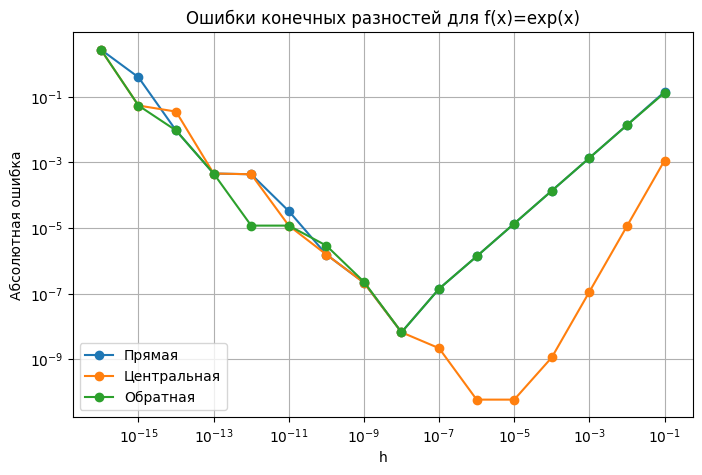

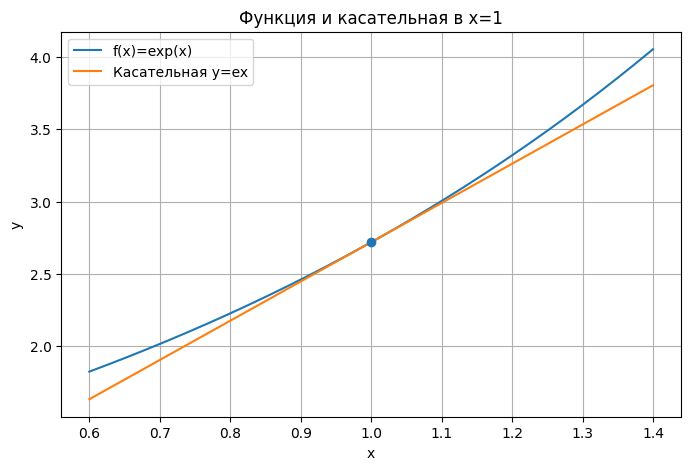

In [4]:
x0 = 1.0
h_values = np.logspace(-1, -16, 16)
exact_derivative = np.exp(x0)

forward = (np.exp(x0 + h_values) - np.exp(x0)) / h_values
central = (np.exp(x0 + h_values / 2) - np.exp(x0 - h_values / 2)) / h_values
backward = (np.exp(x0) - np.exp(x0 - h_values)) / h_values

errors = {
    "Прямая": np.abs(forward - exact_derivative),
    "Центральная": np.abs(central - exact_derivative),
    "Обратная": np.abs(backward - exact_derivative),
}

best_h = {name: h_values[np.argmin(err)] for name, err in errors.items()}
print("Точная производная:", exact_derivative)
print("Лучшие h:", best_h)

plt.figure(figsize=(8, 5))
for name, err in errors.items():
    plt.loglog(h_values, err, marker="o", label=name)
plt.xlabel("h")
plt.ylabel("Абсолютная ошибка")
plt.title("Ошибки конечных разностей для f(x)=exp(x)")
plt.grid(True, which="both")
plt.legend()
plt.show()

x_plot = np.linspace(0.6, 1.4, 200)
plt.figure(figsize=(8, 5))
plt.plot(x_plot, np.exp(x_plot), label="f(x)=exp(x)")
plt.plot(x_plot, exact_derivative * x_plot, label="Касательная y=ex")
plt.scatter([x0], [np.exp(x0)], zorder=3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Функция и касательная в x=1")
plt.grid(True)
plt.legend()
plt.show()


### 2.2. Правила дифференцирования

1. Для $y=2x^3-5x^2+7x+4$:
$$
y'=6x^2-10x+7,\qquad y'(1)=3.
$$

2. Для $y=x^2e^x$ применяется правило произведения:
$$
y'=2xe^x+x^2e^x=e^x(x^2+2x),\qquad y'(1)=3e.
$$

3. Для $y=(2x^2+5)^2$ внешний аргумент $u=2x^2+5$, $y=u^2$:
$$
y'=2u\cdot4x=8x(2x^2+5),\qquad y'(1)=56.
$$

4. Для $y=\ln(2x^3+3x^2)$ внутренний аргумент $u=2x^3+3x^2$:
$$
y'=\frac{6x^2+6x}{2x^3+3x^2}
=\frac{6(x+1)}{x(2x+3)},\qquad y'(1)=\frac{12}{5}=2.4.
$$


In [5]:
functions = [
    lambda x: 2*x**3 - 5*x**2 + 7*x + 4,
    lambda x: x**2 * np.exp(x),
    lambda x: (2*x**2 + 5)**2,
    lambda x: np.log(2*x**3 + 3*x**2),
]
derivative_functions = [
    lambda x: 6*x**2 - 10*x + 7,
    lambda x: np.exp(x) * (x**2 + 2*x),
    lambda x: 8*x * (2*x**2 + 5),
    lambda x: (6*x**2 + 6*x) / (2*x**3 + 3*x**2),
]
h = 1e-5

names = ["1", "2", "3", "4"]
for name, f, df in zip(names, functions, derivative_functions):
    exact = df(1.0)
    numerical = (f(1.0 + h) - f(1.0 - h)) / (2*h)
    print(f"{name}: аналитически={exact:.12f}, центральная разность={numerical:.12f}, ошибка={abs(exact-numerical):.3e}")


1: аналитически=3.000000000000, центральная разность=3.000000000242, ошибка=2.417e-10
2: аналитически=8.154845485377, центральная разность=8.154845485975, ошибка=5.976e-10
3: аналитически=56.000000000000, центральная разность=56.000000002143, ошибка=2.143e-09
4: аналитически=2.400000000000, центральная разность=2.400000000058, ошибка=5.791e-11


### 2.3. Дифференциал и граница дифференцируемости

Для $y=\ln(1+x^2)$:
$$
y'=\frac{2x}{1+x^2},\qquad
dy=\frac{2x}{1+x^2}\,dx.
$$

В точке $x=1$, при $dx=0.02$:
$$
dy=\frac{2}{2}\cdot0.02=0.02.
$$
Точное изменение:
$$
\Delta y=\ln(1+1.02^2)-\ln2.
$$

Для $r(x)=\max(0,x)$:
$$
r'_-(0)=0,\qquad r'_+(0)=1.
$$
Односторонние производные не совпадают, поэтому обычная производная в нуле не существует. При этом центральная разность
$$
\frac{r(h)-r(-h)}{2h}=\frac{h}{2h}=\frac12
$$
возвращает число $1/2$. Это число не является производной: конечная симметричная аппроксимация может скрывать излом функции.


Линейное изменение: 0.02
Точное изменение: 0.019998686506689123
Абсолютная ошибка: 1.3134933108775726e-06
Левая производная ReLU: 0.0
Правая производная ReLU: 1.0
Центральная разность ReLU: 0.5


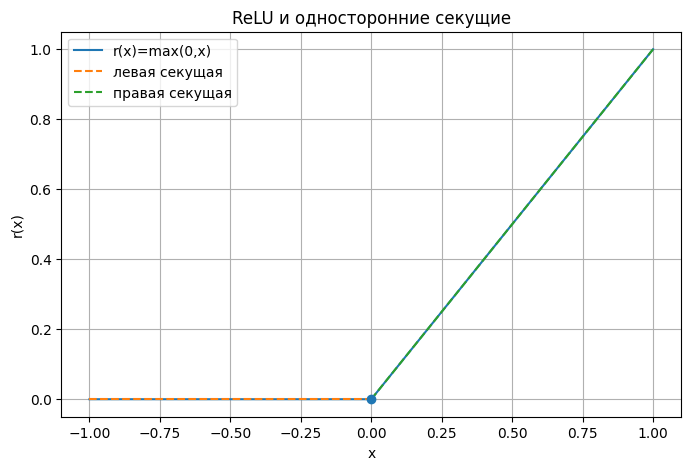

In [6]:
x0, dx = 1.0, 0.02
log_function = lambda x: np.log(1 + x**2)

linear_change = (2*x0 / (1 + x0**2)) * dx
exact_change = log_function(x0 + dx) - log_function(x0)

relu = lambda x: np.maximum(0.0, x)
h = 1e-5
left_diff = (relu(0.0) - relu(-h)) / h
right_diff = (relu(h) - relu(0.0)) / h
central_diff = (relu(h) - relu(-h)) / (2*h)

print("Линейное изменение:", linear_change)
print("Точное изменение:", exact_change)
print("Абсолютная ошибка:", abs(linear_change - exact_change))
print("Левая производная ReLU:", left_diff)
print("Правая производная ReLU:", right_diff)
print("Центральная разность ReLU:", central_diff)

x = np.linspace(-1, 1, 400)
plt.figure(figsize=(8, 5))
plt.plot(x, relu(x), label="r(x)=max(0,x)")
plt.plot([-1, 0], [0, 0], "--", label="левая секущая")
plt.plot([0, 1], [0, 1], "--", label="правая секущая")
plt.scatter([0], [0], zorder=3)
plt.xlabel("x")
plt.ylabel("r(x)")
plt.title("ReLU и односторонние секущие")
plt.grid(True)
plt.legend()
plt.show()


## 3. Частные производные, градиент и дифференциал

### 3.1. Полный дифференциал многочлена

$$
z=5x^3+2x^2y^4-6x+9y.
$$

При $y=\mathrm{const}$:
$$
\frac{\partial z}{\partial x}=15x^2+4xy^4-6.
$$

При $x=\mathrm{const}$:
$$
\frac{\partial z}{\partial y}=8x^2y^3+9.
$$

Поэтому
$$
\nabla z=
\begin{pmatrix}
15x^2+4xy^4-6\\
8x^2y^3+9
\end{pmatrix},
$$
$$
dz=(15x^2+4xy^4-6)\,dx+(8x^2y^3+9)\,dy.
$$

В точке $(1,-1)$:
$$
\nabla z(1,-1)=
\begin{pmatrix}13\\1\end{pmatrix}.
$$
Коэффициенты при $dx$ и $dy$ в полном дифференциале являются соответствующими частными производными, то есть компонентами градиента.


In [7]:
def z_practice(point):
    x, y = point
    return 5*x**3 + 2*x**2*y**4 - 6*x + 9*y

point = np.array([1.0, -1.0])
gradient_exact = np.array([
    15*point[0]**2 + 4*point[0]*point[1]**4 - 6,
    8*point[0]**2*point[1]**3 + 9,
])

gradient_numeric = np.empty(2)
h = 1e-5
for i in range(2):
    e = np.zeros(2)
    e[i] = 1
    gradient_numeric[i] = (z_practice(point + h*e) - z_practice(point - h*e)) / (2*h)

print("Аналитический градиент:", gradient_exact)
print("Численный градиент:", gradient_numeric)
print("Норма ошибки:", np.linalg.norm(gradient_exact - gradient_numeric))


Аналитический градиент: [13.  1.]
Численный градиент: [13.  1.]
Норма ошибки: 8.683816026498536e-10


### 3.2. Локальная плоскость вместо касательной

$$
f(x,y)=x^2+xy+2y^2-3x+1,\qquad x_0=(1,-1)^T.
$$

$$
\nabla f(x,y)=
\begin{pmatrix}
2x+y-3\\
x+4y
\end{pmatrix},
\qquad
\nabla f(x_0)=
\begin{pmatrix}-2\\-3\end{pmatrix}.
$$

$$
f(x_0)=4.
$$

Линейная модель:
$$
f(x_0+\Delta x)\approx f(x_0)+\nabla f(x_0)^T\Delta x.
$$

Для $\Delta x=(0.01,-0.02)^T$:
$$
df=(-2)\cdot0.01+(-3)\cdot(-0.02)=0.04.
$$
Точное изменение будет немного отличаться из-за квадратичных членов. Для функции двух переменных касательная задаётся плоскостью, а не прямой.


f(x0) = 0.0
grad f(x0) = [-2. -3.]
Линейный прогноз изменения = 0.04
Точное изменение = 0.040699999999999736
Ошибка прогноза = 0.0006999999999997356


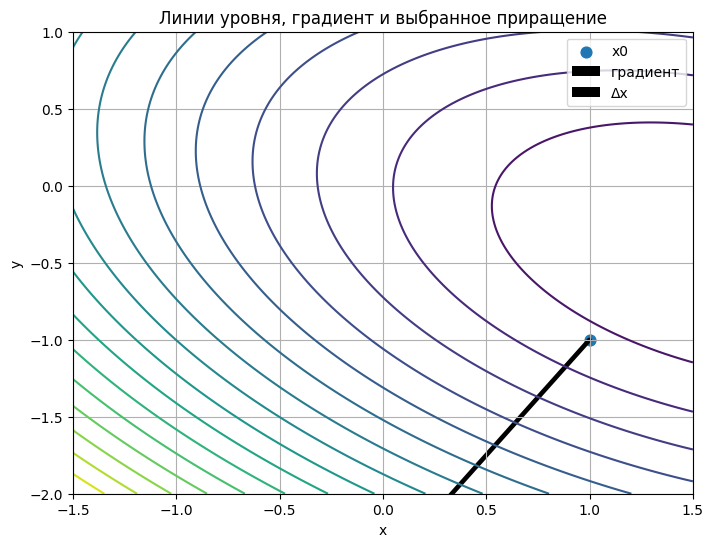

In [8]:
def f_quadratic(point):
    x, y = point
    return x**2 + x*y + 2*y**2 - 3*x + 1

x_base = np.array([1.0, -1.0])
delta = np.array([0.01, -0.02])
gradient_base = np.array([2*x_base[0] + x_base[1] - 3,
                          x_base[0] + 4*x_base[1]])
f_base = f_quadratic(x_base)
linear_change = gradient_base @ delta
exact_change = f_quadratic(x_base + delta) - f_base

print("f(x0) =", f_base)
print("grad f(x0) =", gradient_base)
print("Линейный прогноз изменения =", linear_change)
print("Точное изменение =", exact_change)
print("Ошибка прогноза =", abs(linear_change - exact_change))

xx = np.linspace(-1.5, 1.5, 200)
yy = np.linspace(-2, 1, 200)
XX, YY = np.meshgrid(xx, yy)
ZZ = XX**2 + XX*YY + 2*YY**2 - 3*XX + 1

plt.figure(figsize=(8, 6))
levels = np.linspace(ZZ.min(), ZZ.max(), 18)
plt.contour(XX, YY, ZZ, levels=levels)
plt.scatter(*x_base, s=60, label="x0")
plt.quiver(x_base[0], x_base[1], gradient_base[0], gradient_base[1],
           angles="xy", scale_units="xy", scale=1, label="градиент")
plt.quiver(x_base[0], x_base[1], delta[0], delta[1],
           angles="xy", scale_units="xy", scale=1, label="Δx")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Линии уровня, градиент и выбранное приращение")
plt.grid(True)
plt.legend()
plt.show()


### 3.3. Численный градиент по координатам

Для $i$-й компоненты:
$$
\frac{\partial f}{\partial x_i}(\mathbf x)
\approx
\frac{f(\mathbf x+h\mathbf e_i)-f(\mathbf x-h\mathbf e_i)}{2h}.
$$

В $n$-мерном пространстве центральная разность требует $2n$ обращений к функции, если значение $f(\mathbf x)$ не переиспользуется. Поэтому вычислительная стоимость растёт линейно с числом координат.


In [9]:
def central_gradient(function, point, h=1e-5):
    point = np.asarray(point, dtype=float)
    gradient = np.empty_like(point)
    for i in range(point.size):
        e = np.zeros_like(point)
        e[i] = 1.0
        gradient[i] = (function(point + h*e) - function(point - h*e)) / (2*h)
    return gradient

for h_test in [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]:
    g_num = central_gradient(f_quadratic, x_base, h_test)
    print(f"h={h_test:.0e}: {g_num}, ошибка={np.linalg.norm(g_num-gradient_base):.3e}")

print("Число обращений к f для n координат:", "2n")


h=1e-02: [-2. -3.], ошибка=2.542e-14
h=1e-03: [-2. -3.], ошибка=3.491e-13
h=1e-04: [-2. -3.], ошибка=4.234e-12
h=1e-05: [-2. -3.], ошибка=9.453e-12
h=1e-06: [-2. -3.], ошибка=3.874e-10
Число обращений к f для n координат: 2n


## 4. Производная по направлению и полная производная

### 4.1. Изменение вдоль выбранного направления

$$
v=\frac15(3,4)^T,\qquad \|v\|=1.
$$

В точке $x_0$ градиент равен $(-2,-3)^T$, поэтому
$$
D_vf(x_0)=\nabla f(x_0)^Tv
=(-2)\frac35+(-3)\frac45=-\frac{18}{5}=-3.6.
$$

Функция убывает при движении в направлении $v$. Максимальный рост происходит в направлении
$$
\frac{\nabla f}{\|\nabla f\|}=\frac{(-2,-3)}{\sqrt{13}},
$$
со скоростью $\|\nabla f\|=\sqrt{13}$. Максимальное убывание происходит в противоположном направлении со скоростью $-\sqrt{13}$. Нормировка нужна, чтобы сравнивать скорость изменения на единицу пройденного пути.


D_v f(x0) = -3.6
Направление максимального роста = [-0.5547  -0.83205]
Скорость максимального роста = 3.605551275463989
Направление максимального убывания = [0.5547  0.83205]
Скорость максимального убывания = -3.605551275463989
h=1e-01: численно=-3.600000000000, ошибка=3.109e-15
h=1e-02: численно=-3.600000000000, ошибка=4.130e-14
h=1e-03: численно=-3.599999999999, ошибка=1.285e-12
h=1e-04: численно=-3.600000000006, ошибка=5.821e-12
h=1e-05: численно=-3.599999999970, ошибка=2.971e-11
h=1e-06: численно=-3.599999999881, ошибка=1.185e-10


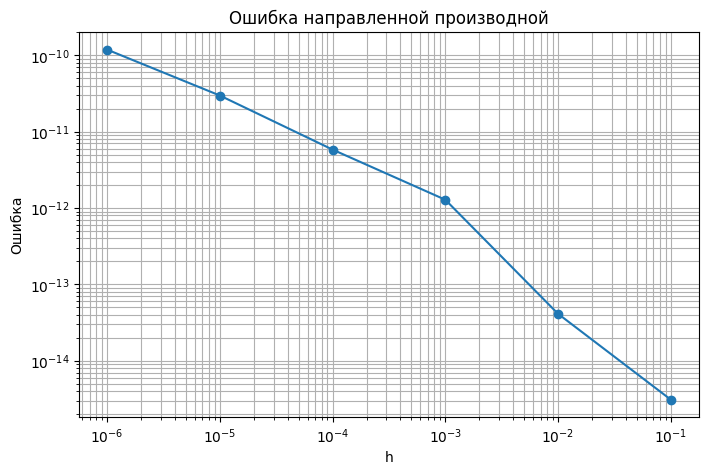

In [10]:
v_direction = np.array([3.0, 4.0]) / 5.0
directional_exact = gradient_base @ v_direction

print("D_v f(x0) =", directional_exact)
print("Направление максимального роста =", gradient_base / np.linalg.norm(gradient_base))
print("Скорость максимального роста =", np.linalg.norm(gradient_base))
print("Направление максимального убывания =", -gradient_base / np.linalg.norm(gradient_base))
print("Скорость максимального убывания =", -np.linalg.norm(gradient_base))

h_tests = np.logspace(-1, -6, 6)
directional_errors = []
for h_test in h_tests:
    numerical = (f_quadratic(x_base + h_test*v_direction/2)
                 - f_quadratic(x_base - h_test*v_direction/2)) / h_test
    directional_errors.append(abs(numerical - directional_exact))
    print(f"h={h_test:.0e}: численно={numerical:.12f}, ошибка={abs(numerical-directional_exact):.3e}")

plt.figure(figsize=(8, 5))
plt.loglog(h_tests, directional_errors, marker="o")
plt.xlabel("h")
plt.ylabel("Ошибка")
plt.title("Ошибка направленной производной")
plt.grid(True, which="both")
plt.show()


### 4.2. Все пути влияния переменной

$$
F(t,x,y)=tx+x^2+xy+2y^2,\qquad x=t,\quad y=t^2.
$$

После подстановки:
$$
F(t)=t^2+t^2+t^3+2t^4=2t^2+t^3+2t^4,
$$
$$
\frac{dF}{dt}=4t+3t^2+8t^3.
$$
При $t=1$:
$$
\frac{dF}{dt}=15.
$$

По правилу полной производной:
$$
\frac{dF}{dt}
=\frac{\partial F}{\partial t}
+\frac{\partial F}{\partial x}\frac{dx}{dt}
+\frac{\partial F}{\partial y}\frac{dy}{dt}.
$$

Здесь учитываются прямой путь $t\to F$, путь $t\to x\to F$ и путь $t\to y\to F$. Пропуск любого пути даёт неполную производную.


In [11]:
def F_total(t, x, y):
    return t*x + x**2 + x*y + 2*y**2

def F_substituted(t):
    return F_total(t, t, t**2)

def direct_substitution_derivative(t):
    return 4*t + 3*t**2 + 8*t**3

def total_derivative_formula(t):
    x, y = t, t**2
    dF_dt = x
    dF_dx = t + 2*x + y
    dF_dy = x + 4*y
    dx_dt = 1.0
    dy_dt = 2*t
    return dF_dt + dF_dx*dx_dt + dF_dy*dy_dt

t0 = 1.0
h = 1e-5
central_total = (F_substituted(t0+h) - F_substituted(t0-h)) / (2*h)

print("После подстановки:", direct_substitution_derivative(t0))
print("По полной производной:", total_derivative_formula(t0))
print("Центральная разность:", central_total)


После подстановки: 15.0
По полной производной: 15.0
Центральная разность: 15.000000000942036


## 5. Якобиан, JVP, VJP и цепное правило

### 5.1. Якобиан

$$
f(x_1,x_2)=
\begin{pmatrix}
x_1^2+x_2\\
e^{x_1-x_2}\\
x_1x_2
\end{pmatrix}.
$$

Вход имеет размерность $2$, выход — $3$, поэтому $J_f\in\mathbb R^{3\times2}$:
$$
J_f=
\begin{pmatrix}
2x_1&1\\
e^{x_1-x_2}&-e^{x_1-x_2}\\
x_2&x_1
\end{pmatrix}.
$$

В точке $x_*=(1,0)^T$:
$$
f(x_*)=(1,e,0)^T,
\quad
J_f(x_*)=
\begin{pmatrix}
2&1\\
e&-e\\
0&1
\end{pmatrix}.
$$

Элемент $J_{ij}$ — производная $i$-й компоненты выхода по $j$-й входной координате. Градиенты компонент выхода расположены по строкам, поэтому число строк равно числу выходов.


In [12]:
def vector_function(point):
    x1, x2 = point
    return np.array([x1**2 + x2, np.exp(x1 - x2), x1*x2])

x_star = np.array([1.0, 0.0])

def jacobian_exact(point):
    x1, x2 = point
    e = np.exp(x1 - x2)
    return np.array([
        [2*x1, 1.0],
        [e, -e],
        [x2, x1],
    ])

J_star = jacobian_exact(x_star)
print("f(x*) =", vector_function(x_star))
print("J(x*) =\n", J_star)

h = 1e-5
J_numeric = np.empty_like(J_star)
for j in range(2):
    e_j = np.zeros(2)
    e_j[j] = 1.0
    J_numeric[:, j] = (vector_function(x_star+h*e_j) -
                       vector_function(x_star-h*e_j)) / (2*h)

print("Численный J =\n", J_numeric)
print("Норма ошибки =", np.linalg.norm(J_star-J_numeric))


f(x*) = [1.       2.718282 0.      ]
J(x*) =
 [[ 2.        1.      ]
 [ 2.718282 -2.718282]
 [ 0.        1.      ]]
Численный J =
 [[ 2.        1.      ]
 [ 2.718282 -2.718282]
 [ 0.        1.      ]]
Норма ошибки = 8.288458036275357e-11


### 5.2. JVP

Для $v=(1,-2)^T$:
$$
J_f(x_*)v=
\begin{pmatrix}
2&1\\e&-e\\0&1
\end{pmatrix}
\begin{pmatrix}1\\-2\end{pmatrix}
=
\begin{pmatrix}
0\\3e\\-2
\end{pmatrix}.
$$

Численно:
$$
J_f(x_*)v\approx
\frac{f(x_*+hv/2)-f(x_*-hv/2)}{h}.
$$

Нужны только два обращения к $f$, независимо от числа входных координат.


h=1e-01: численно=[ 0.        8.185461 -2.      ], ошибка=3.062e-02
h=1e-02: численно=[-0.        8.155151 -2.      ], ошибка=3.058e-04
h=1e-03: численно=[ 0.        8.154849 -2.      ], ошибка=3.058e-06
h=1e-04: численно=[ 0.        8.154846 -2.      ], ошибка=3.059e-08
h=1e-05: численно=[ 0.        8.154845 -2.      ], ошибка=3.534e-10
h=1e-06: численно=[ 0.        8.154845 -2.      ], ошибка=2.832e-10
Точный JVP: [ 0.        8.154845 -2.      ]


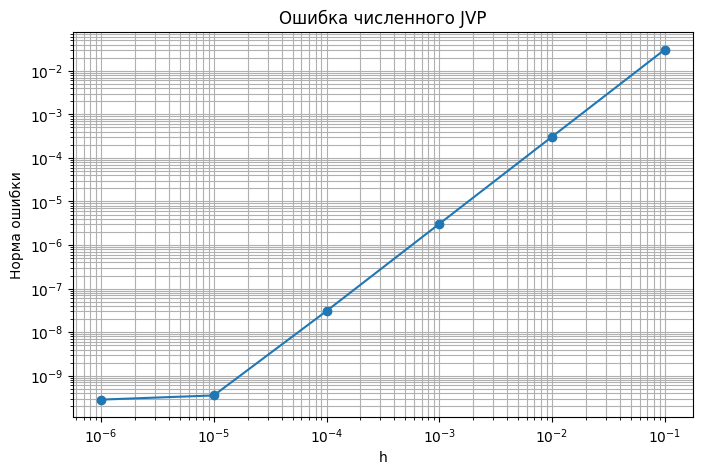

In [13]:
v_jvp = np.array([1.0, -2.0])
exact_jvp = J_star @ v_jvp

h_values = np.logspace(-1, -6, 6)
jvp_errors = []
for h_test in h_values:
    numerical_jvp = (vector_function(x_star + h_test*v_jvp/2)
                     - vector_function(x_star - h_test*v_jvp/2)) / h_test
    jvp_errors.append(np.linalg.norm(numerical_jvp - exact_jvp))
    print(f"h={h_test:.0e}: численно={numerical_jvp}, ошибка={jvp_errors[-1]:.3e}")

print("Точный JVP:", exact_jvp)

plt.figure(figsize=(8, 5))
plt.loglog(h_values, jvp_errors, marker="o")
plt.xlabel("h")
plt.ylabel("Норма ошибки")
plt.title("Ошибка численного JVP")
plt.grid(True, which="both")
plt.show()


### 5.3. VJP и производная композиции

Для $u=(1,2,-1)^T$:
$$
u^TJ_f(x_*)=(1,2,-1)
\begin{pmatrix}
2&1\\e&-e\\0&1
\end{pmatrix}
=
(2+2e,\,-1-2e).
$$

Пусть
$$
g(z)=\frac12\|z-c\|^2,\qquad c=(0,1,1)^T.
$$
Тогда
$$
\nabla_zg=z-c.
$$

В точке $x_*$:
$$
f(x_*)-c=(1,e-1,-1)^T.
$$

Следовательно,
$$
\nabla_xh=J_f(x_*)^T(f(x_*)-c)
=
\begin{pmatrix}
e+1\\
2-e
\end{pmatrix}.
$$
Размерности: $J_f^T\in\mathbb R^{2\times3}$, $\nabla_zg\in\mathbb R^3$, результат $\in\mathbb R^2$.


In [14]:
u_vjp = np.array([1.0, 2.0, -1.0])
c_target = np.array([0.0, 1.0, 1.0])

vjp = u_vjp @ J_star

def composition_loss(point):
    residual = vector_function(point) - c_target
    return 0.5 * np.dot(residual, residual)

grad_z = vector_function(x_star) - c_target
grad_composition = J_star.T @ grad_z
grad_numeric = central_gradient(composition_loss, x_star, 1e-5)

print("u^T J =", vjp)
print("grad_z g =", grad_z)
print("Аналитический grad_x h =", grad_composition)
print("Численный grad_x h =", grad_numeric)
print("Норма ошибки =", np.linalg.norm(grad_composition-grad_numeric))


u^T J = [ 7.436564 -5.436564]
grad_z g = [ 1.        1.718282 -1.      ]
Аналитический grad_x h = [ 6.670774 -4.670774]
Численный grad_x h = [ 6.670774 -4.670774]
Норма ошибки = 8.15363047149833e-10


## 6. Гессиан и кривизна

### 6.1. Положительная кривизна и минимум

$$
z=2x^2+y^2+x-3y+2xy.
$$

Условия стационарности:
$$
4x+2y+1=0,\qquad 2x+2y-3=0.
$$
Отсюда
$$
(x_*,y_*)=(-2,\,7/2).
$$

Гессиан:
$$
H=
\begin{pmatrix}4&2\\2&2\end{pmatrix},
\qquad \det H=4>0.
$$
Собственные значения:
$$
\lambda_{1,2}=3\pm\sqrt5,
$$
оба положительны. Поэтому стационарная точка — строгий локальный минимум. Значение функции:
$$
z(x_*,y_*)=-\frac{29}{4}=-7.25.
$$


Стационарная точка: [-2.   3.5]
Hessian:
 [[4. 2.]
 [2. 2.]]
det(H) = 4.0
Собственные значения: [0.763932 5.236068]
z(x*) = -6.25


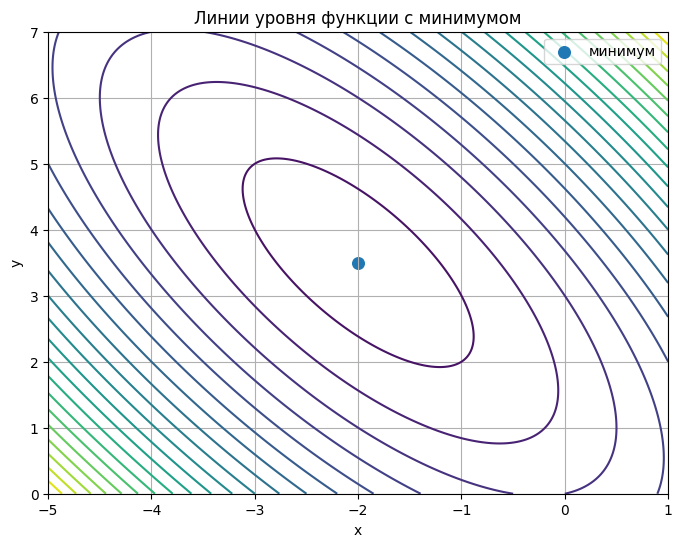

In [15]:
def minimum_function(point):
    x, y = point
    return 2*x**2 + y**2 + x - 3*y + 2*x*y

minimum_point = np.array([-2.0, 3.5])
H_min = np.array([[4.0, 2.0], [2.0, 2.0]])
eig_min = np.linalg.eigvalsh(H_min)

print("Стационарная точка:", minimum_point)
print("Hessian:\n", H_min)
print("det(H) =", np.linalg.det(H_min))
print("Собственные значения:", eig_min)
print("z(x*) =", minimum_function(minimum_point))

xx = np.linspace(-5, 1, 250)
yy = np.linspace(0, 7, 250)
XX, YY = np.meshgrid(xx, yy)
ZZ = 2*XX**2 + YY**2 + XX - 3*YY + 2*XX*YY

plt.figure(figsize=(8, 6))
plt.contour(XX, YY, ZZ, levels=20)
plt.scatter(*minimum_point, s=70, label="минимум")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Линии уровня функции с минимумом")
plt.grid(True)
plt.legend()
plt.show()


### 6.2. Неопределённая кривизна и седло

$$
z=x^2-2y^2-4xy+3x.
$$

Условия стационарности:
$$
2x-4y+3=0,\qquad -4y-4x=0.
$$
Получаем
$$
(x_*,y_*)=(-1.5,-1.5).
$$

Гессиан:
$$
H=
\begin{pmatrix}
2&-4\\
-4&-4
\end{pmatrix},
\qquad
\det H=-24<0.
$$
Собственные значения имеют разные знаки:
$$
\lambda=-1\pm\sqrt{41}.
$$
Поэтому точка является седловой.

Разные знаки кривизны можно увидеть, например, вдоль направлений $e_1=(1,0)^T$ и $e_2=(0,1)^T$:
$$
e_1^THe_1=2>0,\qquad e_2^THe_2=-4<0.
$$
Следовательно, нулевой градиент сам по себе не гарантирует минимум.


Стационарная точка: [-1.5 -1.5]
Hessian:
 [[ 2. -4.]
 [-4. -4.]]
det(H) = -23.999999999999993
Собственные значения: [-6.  4.]
Кривизна вдоль e1: 2.0
Кривизна вдоль e2: -4.0


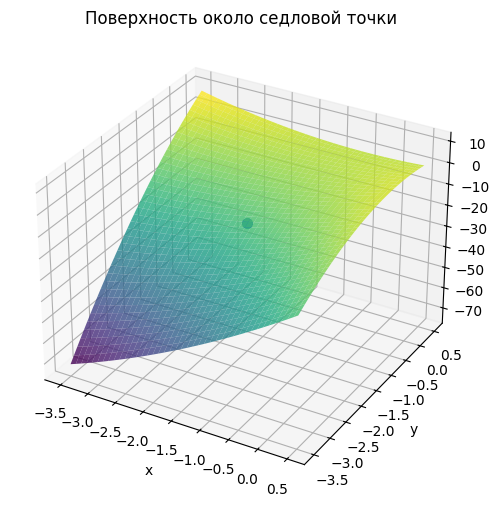

In [16]:
def saddle_function(point):
    x, y = point
    return x**2 - 2*y**2 - 4*x*y + 3*x

saddle_point = np.array([-1.5, -1.5])
H_saddle = np.array([[2.0, -4.0], [-4.0, -4.0]])
eig_saddle = np.linalg.eigvalsh(H_saddle)

print("Стационарная точка:", saddle_point)
print("Hessian:\n", H_saddle)
print("det(H) =", np.linalg.det(H_saddle))
print("Собственные значения:", eig_saddle)
print("Кривизна вдоль e1:", np.array([1.,0.]) @ H_saddle @ np.array([1.,0.]))
print("Кривизна вдоль e2:", np.array([0.,1.]) @ H_saddle @ np.array([0.,1.]))

xx = np.linspace(-3.5, 0.5, 160)
yy = np.linspace(-3.5, 0.5, 160)
XX, YY = np.meshgrid(xx, yy)
ZZ = XX**2 - 2*YY**2 - 4*XX*YY + 3*XX

plt.figure(figsize=(8, 6))
ax = plt.axes(projection="3d")
ax.plot_surface(XX, YY, ZZ, cmap="viridis", linewidth=0, alpha=0.8)
ax.scatter([saddle_point[0]], [saddle_point[1]], [saddle_function(saddle_point)], s=50)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Поверхность около седловой точки")
plt.show()


### 6.3. Квадратичная модель и HVP

$$
\varphi(x,y)=e^{x+2y}+x^2.
$$

$$
\nabla\varphi=
\begin{pmatrix}
e^{x+2y}+2x\\
2e^{x+2y}
\end{pmatrix},
\quad
H_\varphi=
\begin{pmatrix}
e^{x+2y}+2&2e^{x+2y}\\
2e^{x+2y}&4e^{x+2y}
\end{pmatrix}.
$$

В $(0,0)$:
$$
\nabla\varphi=(1,2)^T,\qquad
H_\varphi=\begin{pmatrix}3&2\\2&4\end{pmatrix}.
$$

Для $\Delta=(0.1,0.1)^T$:
$$
\varphi(0,0)=1,
$$
$$
\varphi_{\text{lin}}=1+(1,2)\Delta=1.3,
$$
$$
\varphi_{\text{quad}}=1.3+\frac12\Delta^TH\Delta=1.335.
$$

Для $v=(1,-1)^T$:
$$
Hv=(1,-2)^T.
$$
Квадратичный член учитывает изменение самого градиента и локальную кривизну, поэтому обычно даёт более точное приближение при малых приращениях.


grad phi(0) = [1. 2.]
H phi(0) =
 [[3. 2.]
 [2. 4.]]
H v = [ 1. -2.]
Точное значение: 1.3598588075760032
Линейное приближение: 1.3
Квадратичное приближение: 1.355


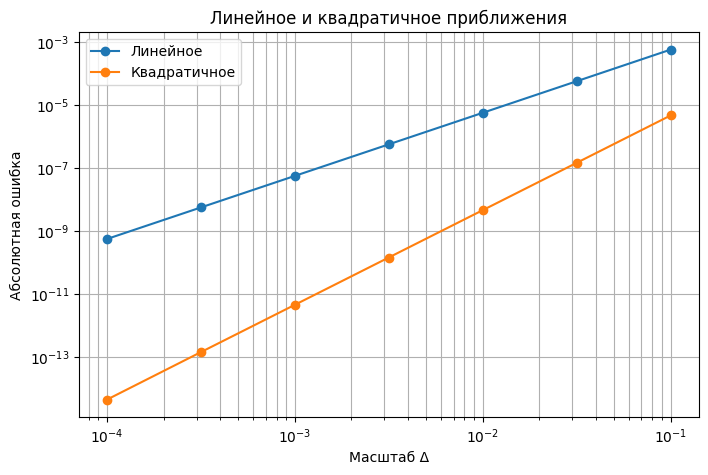

In [17]:
def phi(point):
    x, y = point
    return np.exp(x + 2*y) + x**2

def phi_gradient(point):
    x, y = point
    e = np.exp(x + 2*y)
    return np.array([e + 2*x, 2*e])

def phi_hessian(point):
    x, y = point
    e = np.exp(x + 2*y)
    return np.array([[e + 2, 2*e], [2*e, 4*e]])

phi0 = np.array([0.0, 0.0])
g0 = phi_gradient(phi0)
H0 = phi_hessian(phi0)
delta_phi = np.array([0.1, 0.1])
v_phi = np.array([1.0, -1.0])

linear_approx = phi(phi0) + g0 @ delta_phi
quadratic_approx = linear_approx + 0.5 * delta_phi @ H0 @ delta_phi

print("grad phi(0) =", g0)
print("H phi(0) =\n", H0)
print("H v =", H0 @ v_phi)
print("Точное значение:", phi(delta_phi))
print("Линейное приближение:", linear_approx)
print("Квадратичное приближение:", quadratic_approx)

scales = np.logspace(-1, -4, 7)
linear_errors = []
quadratic_errors = []
for s in scales:
    d = s * delta_phi
    exact = phi(d)
    lin = phi(phi0) + g0 @ d
    quad = lin + 0.5 * d @ H0 @ d
    linear_errors.append(abs(exact-lin))
    quadratic_errors.append(abs(exact-quad))

plt.figure(figsize=(8, 5))
plt.loglog(scales, linear_errors, marker="o", label="Линейное")
plt.loglog(scales, quadratic_errors, marker="o", label="Квадратичное")
plt.xlabel("Масштаб Δ")
plt.ylabel("Абсолютная ошибка")
plt.title("Линейное и квадратичное приближения")
plt.grid(True, which="both")
plt.legend()
plt.show()


## 7. Матричное дифференцирование

### 7.1. Линейно-квадратичная форма

$$
f(x)=a^Tx+x^TAx,
\quad
A=\begin{pmatrix}2&-1\\3&1\end{pmatrix},
\quad
a=\begin{pmatrix}1\\-2\end{pmatrix},
\quad
x=\begin{pmatrix}2\\-1\end{pmatrix}.
$$

Покоординатно:
$$
f=x_1-2x_2+2x_1^2+2x_1x_2+x_2^2.
$$

Градиент:
$$
\nabla f=a+(A+A^T)x.
$$

$$
A+A^T=
\begin{pmatrix}4&2\\2&2\end{pmatrix},
$$
поэтому
$$
\nabla f=
\begin{pmatrix}1\\-2\end{pmatrix}
+
\begin{pmatrix}4&2\\2&2\end{pmatrix}
\begin{pmatrix}2\\-1\end{pmatrix}
=
\begin{pmatrix}7\\0\end{pmatrix}.
$$

Гессиан:
$$
H=A+A^T=
\begin{pmatrix}4&2\\2&2\end{pmatrix}.
$$

Значение:
$$
f(x)=2.
$$

Появление $A+A^T$ связано с тем, что при дифференцировании $x^TAx$ учитываются оба положения $x$. Кососимметричная часть $K=(A-A^T)/2$ не влияет на квадратичную форму, поскольку $x^TKx=0$.


In [18]:
A_quad = np.array([[2, -1], [3, 1]], dtype=float)
a_quad = np.array([1.0, -2.0])
x_quad = np.array([2.0, -1.0])

def quadratic_form(point):
    return a_quad @ point + point @ A_quad @ point

grad_quad = a_quad + (A_quad + A_quad.T) @ x_quad
H_quad = A_quad + A_quad.T

K_quad = 0.5 * (A_quad - A_quad.T)
print("f(x) =", quadratic_form(x_quad))
print("Аналитический градиент:", grad_quad)
print("Гессиан:\n", H_quad)
print("Кососимметричная часть K:\n", K_quad)
print("x^T K x =", x_quad @ K_quad @ x_quad)

h = 1e-5
g_num = central_gradient(quadratic_form, x_quad, h)
print("Численный градиент:", g_num)
print("Ошибка градиента:", np.linalg.norm(grad_quad-g_num))

H_num = np.empty((2, 2))
for j in range(2):
    e = np.zeros(2); e[j] = 1
    H_num[:, j] = (central_gradient(quadratic_form, x_quad+h*e, h)
                   - central_gradient(quadratic_form, x_quad-h*e, h)) / (2*h)
print("Численный гессиан:\n", H_num)
print("Ошибка гессиана:", np.linalg.norm(H_quad-H_num))


f(x) = 9.0
Аналитический градиент: [7. 0.]
Гессиан:
 [[4. 2.]
 [2. 2.]]
Кососимметричная часть K:
 [[ 0. -2.]
 [ 2.  0.]]
x^T K x = 0.0
Численный градиент: [ 7. -0.]
Ошибка градиента: 1.2663586786024652e-10
Численный гессиан:
 [[4.       1.999996]
 [1.999996 2.      ]]
Ошибка гессиана: 6.057656635884773e-06


### 7.2. Производная по матрице

$$
s(M)=a^TMb,\quad
a=(1,-2)^T,\quad b=(3,1,-1)^T.
$$

Индексная запись:
$$
s=\sum_i\sum_j a_iM_{ij}b_j.
$$
Отсюда
$$
\frac{\partial s}{\partial M_{ij}}=a_i b_j,
$$
то есть
$$
\nabla_Ms=ab^T=
\begin{pmatrix}
3&1&-1\\
-6&-2&2
\end{pmatrix}.
$$

Также:
$$
s=\operatorname{tr}(a^TMb)=\operatorname{tr}(ba^TM),
$$
что согласуется с правилом производной через след. Градиент имеет ту же форму $2\times3$, что и матрица $M$.


In [19]:
a_matrix = np.array([1.0, -2.0])
b_matrix = np.array([3.0, 1.0, -1.0])
M_parameter = np.array([[1, 2, 0], [-1, 3, 4]], dtype=float)

def matrix_scalar(M):
    return a_matrix @ M @ b_matrix

grad_M_exact = np.outer(a_matrix, b_matrix)
s_value = matrix_scalar(M_parameter)

grad_M_numeric = np.zeros_like(M_parameter)
h = 1e-6
for i in range(M_parameter.shape[0]):
    for j in range(M_parameter.shape[1]):
        M_plus = M_parameter.copy()
        M_minus = M_parameter.copy()
        M_plus[i, j] += h
        M_minus[i, j] -= h
        grad_M_numeric[i, j] = (matrix_scalar(M_plus)-matrix_scalar(M_minus))/(2*h)

print("s(M) =", s_value)
print("Аналитический градиент:\n", grad_M_exact)
print("Численный градиент:\n", grad_M_numeric)
print("Максимальная ошибка:", np.max(np.abs(grad_M_exact-grad_M_numeric)))


s(M) = 13.0
Аналитический градиент:
 [[ 3.  1. -1.]
 [-6. -2.  2.]]
Численный градиент:
 [[ 3.  1. -1.]
 [-6. -2.  2.]]
Максимальная ошибка: 1.0279563866788521e-09


### 7.3. Сумма потерь, след и матричный градиент

$$
Q(W)=\frac1{2N}\|XW-Y\|_F^2.
$$

Три эквивалентные формы:
$$
Q=\frac1{2N}\sum_{n,k}
\left(\sum_dX_{nd}W_{dk}-Y_{nk}\right)^2,
$$
$$
Q=\frac1{2N}\|XW-Y\|_F^2,
$$
$$
Q=\frac1{2N}\operatorname{tr}\left((XW-Y)^T(XW-Y)\right).
$$

Обозначим $R=XW-Y$. Тогда
$$
\nabla_WQ=\frac1N X^TR.
$$

Действие гессиана на направление $\Delta W$:
$$
H_Q[\Delta W]=\frac1N X^TX\Delta W.
$$

Индекс $d,k$ у градиента совпадает с индексами параметра $W_{dk}$, поэтому размерность градиента $D\times K=3\times2$.


In [20]:
def matrix_least_squares(W):
    residual = X_data @ W - Y_data
    return 0.5 * np.sum(residual**2) / len(X_data)

def matrix_ls_gradient(W):
    return X_data.T @ (X_data @ W - Y_data) / len(X_data)

def matrix_ls_hessian_action(delta_W):
    return X_data.T @ X_data @ delta_W / len(X_data)

Q_initial = matrix_least_squares(W_initial)
grad_Q = matrix_ls_gradient(W_initial)

print("Q(W0) =", Q_initial)
print("grad_W Q(W0):\n", grad_Q)

grad_Q_numeric = np.zeros_like(W_initial)
h = 1e-6
for i in range(W_initial.shape[0]):
    for j in range(W_initial.shape[1]):
        Wp = W_initial.copy(); Wm = W_initial.copy()
        Wp[i,j] += h; Wm[i,j] -= h
        grad_Q_numeric[i,j] = (matrix_least_squares(Wp)-matrix_least_squares(Wm))/(2*h)

print("Численный градиент:\n", grad_Q_numeric)
print("Максимальная ошибка:", np.max(np.abs(grad_Q-grad_Q_numeric)))

direction_W = np.ones_like(W_initial)
print("Hessian action на ΔW=1:\n", matrix_ls_hessian_action(direction_W))


Q(W0) = 0.3775
grad_W Q(W0):
 [[ 0.125 -0.425]
 [-0.2   -0.2  ]
 [-0.325  0.325]]
Численный градиент:
 [[ 0.125 -0.425]
 [-0.2   -0.2  ]
 [-0.325  0.325]]
Максимальная ошибка: 3.228772804675373e-11
Hessian action на ΔW=1:
 [[0. 0.]
 [2. 2.]
 [1. 1.]]


## 8. Сквозная составная функция

Пусть
$$
Z=XW+\mathbf1_Nb^T,\qquad H=\sigma(Z),
$$
$$
\mathcal L(W,b)=\frac1{2N}\|H-Y\|_F^2+\frac{\lambda}{2}\|W\|_F^2.
$$

### 8.1. Прямое вычисление

$$
Z_{nk}=\sum_{d=1}^D X_{nd}W_{dk}+b_k,
\qquad
H_{nk}=\sigma(Z_{nk}).
$$

$$
\mathcal L=
\frac1{2N}\sum_{n,k}(H_{nk}-Y_{nk})^2
+\frac{\lambda}{2}\sum_{d,k}W_{dk}^2.
$$

Размерности:

| Объект | Тип | Размерность |
|---|---|---|
| $X$ | матрица | $4\times3$ |
| $W$ | матрица | $3\times2$ |
| $b$ | вектор | $2$ |
| $Z$ | матрица | $4\times2$ |
| $H$ | матрица | $4\times2$ |
| $Y$ | матрица | $4\times2$ |
| $\mathcal L$ | скаляр | $1$ |

Добавление $b$ выполняется поэлементно с расширением вектора по строкам: один и тот же $b_k$ добавляется к каждой строке $Z$.


In [21]:
W = W_initial.copy()
b = b_initial.copy()
N = len(X_data)

Z = X_data @ W + b
H = sigmoid(Z)
residual = H - Y_data
data_loss = 0.5 * np.sum(residual**2) / N
reg_loss = regularization / 2 * np.sum(W**2)
loss = data_loss + reg_loss

print("Z =\n", Z)
print("H =\n", H)
print("Размерности:")
print("X", X_data.shape, "W", W.shape, "b", b.shape, "Z", Z.shape, "H", H.shape, "Y", Y_data.shape)
print("Потеря на данных:", data_loss)
print("Регуляризация:", reg_loss)
print("Полная L:", loss)

z11_manual = X_data[0] @ W[:,0] + b[0]
print("Z[0,0] вручную =", z11_manual)
print("Z[0,0] через матричное вычисление =", Z[0,0])


Z =
 [[ 0.8 -0.7]
 [ 0.   0.1]
 [ 0.7 -0.4]
 [ 0.2  0.5]]
H =
 [[0.689974 0.331812]
 [0.5      0.524979]
 [0.668188 0.401312]
 [0.549834 0.622459]]
Размерности:
X (4, 3) W (3, 2) b (2,) Z (4, 2) H (4, 2) Y (4, 2)
Потеря на данных: 0.12048910430482579
Регуляризация: 0.014750000000000003
Полная L: 0.1352391043048258
Z[0,0] вручную = 0.7999999999999999
Z[0,0] через матричное вычисление = 0.7999999999999999


### 8.2. Распространение производных

Обозначим $R=H-Y$. Тогда:

$$
G_H=\frac1N R\in\mathbb R^{4\times2},
$$

$$
G_Z=G_H\odot H\odot(1-H)\in\mathbb R^{4\times2}.
$$

Следовательно,
$$
\nabla_W\mathcal L=X^TG_Z+\lambda W\in\mathbb R^{3\times2},
$$
$$
\nabla_b\mathcal L=G_Z^T\mathbf1_N\in\mathbb R^2.
$$

Слагаемое $\lambda W$ появляется из производной регуляризатора
$$
\frac{\lambda}{2}\|W\|_F^2.
$$
Производные проходят по композиции в обратном направлении: от $\mathcal L$ к $H$, затем к $Z$, затем к $W,b$.


In [22]:
def objective_and_grad(W, b):
    Z = X_data @ W + b
    H = sigmoid(Z)
    residual = H - Y_data

    data_loss = 0.5 * np.sum(residual**2) / N
    reg_loss = regularization / 2 * np.sum(W**2)
    loss = data_loss + reg_loss

    G_H = residual / N
    G_Z = G_H * H * (1 - H)
    grad_W = X_data.T @ G_Z + regularization * W
    grad_b = np.sum(G_Z, axis=0)

    return loss, grad_W, grad_b

loss0, grad_W0, grad_b0 = objective_and_grad(W_initial, b_initial)
print("L0 =", loss0)
print("grad_W shape:", grad_W0.shape)
print("grad_b shape:", grad_b0.shape)
print("grad_W =\n", grad_W0)
print("grad_b =", grad_b0)


L0 = 0.1352391043048258
grad_W shape: (3, 2)
grad_b shape: (2,)
grad_W =
 [[ 0.012147 -0.024566]
 [ 0.06695  -0.001038]
 [-0.035867  0.04614 ]]
grad_b = [ 0.045317 -0.015683]


### 8.3. Проверка каждого параметра

Для одного параметра:
$$
\frac{\partial\mathcal L}{\partial W_{dk}}
\approx
\frac{\mathcal L(W+hE_{dk},b)-\mathcal L(W-hE_{dk},b)}{2h}.
$$

Для $b_k$:
$$
\frac{\partial\mathcal L}{\partial b_k}
\approx
\frac{\mathcal L(W,b+h e_k)-\mathcal L(W,b-h e_k)}{2h}.
$$

Проверка проводится для каждого элемента обоих параметров. Требование работы — максимальная ошибка меньше $10^{-6}$.


In [23]:
def numerical_parameter_gradients(W, b, h=1e-6):
    grad_W = np.zeros_like(W)
    grad_b = np.zeros_like(b)

    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            W_plus = W.copy()
            W_minus = W.copy()
            W_plus[i,j] += h
            W_minus[i,j] -= h
            grad_W[i,j] = (objective_and_grad(W_plus, b)[0]
                           - objective_and_grad(W_minus, b)[0]) / (2*h)

    for j in range(b.size):
        b_plus = b.copy()
        b_minus = b.copy()
        b_plus[j] += h
        b_minus[j] -= h
        grad_b[j] = (objective_and_grad(W, b_plus)[0]
                     - objective_and_grad(W, b_minus)[0]) / (2*h)

    return grad_W, grad_b

grad_W_num, grad_b_num = numerical_parameter_gradients(W_initial, b_initial)

abs_error_W = np.abs(grad_W0-grad_W_num)
abs_error_b = np.abs(grad_b0-grad_b_num)
max_abs_error = max(abs_error_W.max(), abs_error_b.max())

den_W = np.maximum(np.abs(grad_W0), np.abs(grad_W_num))
den_b = np.maximum(np.abs(grad_b0), np.abs(grad_b_num))
rel_error_W = abs_error_W / np.maximum(den_W, 1e-12)
rel_error_b = abs_error_b / np.maximum(den_b, 1e-12)
max_rel_error = max(rel_error_W.max(), rel_error_b.max())

print("Аналитический grad_W:\n", grad_W0)
print("Численный grad_W:\n", grad_W_num)
print("Аналитический grad_b:", grad_b0)
print("Численный grad_b:", grad_b_num)
print("Максимальная абсолютная ошибка:", max_abs_error)
print("Максимальная относительная ошибка:", max_rel_error)
print("Проверка < 1e-6:", max_abs_error < 1e-6)


Аналитический grad_W:
 [[ 0.012147 -0.024566]
 [ 0.06695  -0.001038]
 [-0.035867  0.04614 ]]
Численный grad_W:
 [[ 0.012147 -0.024566]
 [ 0.06695  -0.001038]
 [-0.035867  0.04614 ]]
Аналитический grad_b: [ 0.045317 -0.015683]
Численный grad_b: [ 0.045317 -0.015683]
Максимальная абсолютная ошибка: 7.289273351585024e-12
Максимальная относительная ошибка: 6.319511223584746e-09
Проверка < 1e-6: True


## 9. Численная оптимизация

Используется градиентный спуск:
$$
W^{(r+1)}=W^{(r)}-\eta\nabla_W\mathcal L,
\qquad
b^{(r+1)}=b^{(r)}-\eta\nabla_b\mathcal L.
$$

Начальная точка одна и та же для всех трёх значений $\eta$: $0.1,1,20$. Для каждого шага сохраняются 100 значений функции и нормы объединённого градиента.

Для достаточно малого положительного $\eta$:
$$
\mathcal L(\theta-\eta\nabla\mathcal L)
\approx
\mathcal L(\theta)-\eta\|\nabla\mathcal L\|^2,
$$
поэтому первое изменение должно быть отрицательным, если градиент ненулевой.


eta | начальное | конечное | минимум | лучшая итерация | увеличений
0.1 | 0.135239104 | 0.085896912 | 0.085896912 |             100 | 0
1.0 | 0.135239104 | 0.073133897 | 0.073133897 |             100 | 0
20.0 | 0.135239104 | 0.252593429 | 0.116681904 |               5 | 51


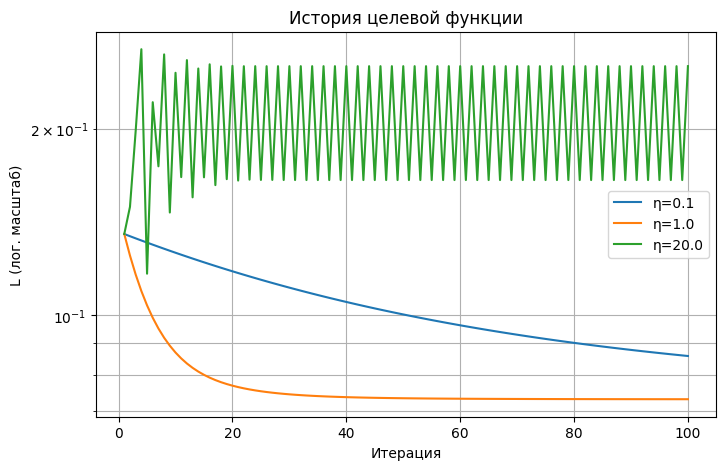

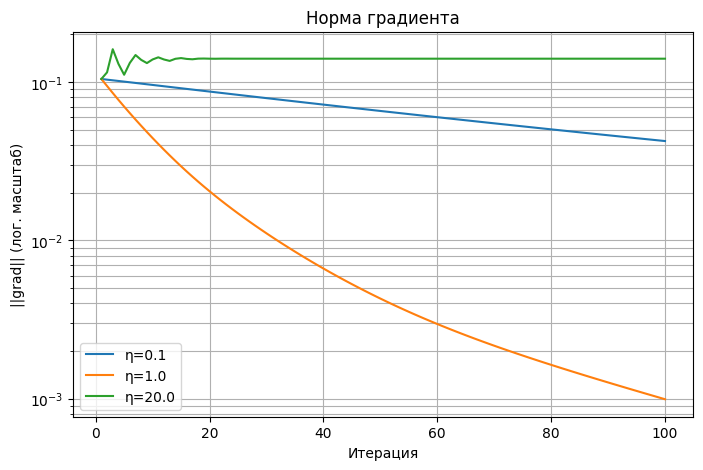

In [24]:
learning_rates = [0.1, 1.0, 20.0]
iterations = 100

optimization_results = {}

for eta in learning_rates:
    W = W_initial.copy()
    b = b_initial.copy()
    loss_history = []
    grad_norm_history = []

    for _ in range(iterations):
        loss, grad_W, grad_b = objective_and_grad(W, b)
        loss_history.append(loss)
        grad_norm_history.append(np.sqrt(np.sum(grad_W**2) + np.sum(grad_b**2)))
        W -= eta * grad_W
        b -= eta * grad_b

    optimization_results[eta] = {
        "loss": np.array(loss_history),
        "grad_norm": np.array(grad_norm_history),
        "W_final": W,
        "b_final": b,
    }

summary_rows = []
for eta in learning_rates:
    history = optimization_results[eta]["loss"]
    increases = np.sum(np.diff(history) > 0)
    best_idx = int(np.argmin(history))
    summary_rows.append([
        eta,
        history[0],
        history[-1],
        history.min(),
        best_idx + 1,
        int(increases),
    ])

print("eta | начальное | конечное | минимум | лучшая итерация | увеличений")
for row in summary_rows:
    print(f"{row[0]:>3} | {row[1]:.9f} | {row[2]:.9f} | {row[3]:.9f} | {row[4]:>15} | {row[5]}")

plt.figure(figsize=(8, 5))
for eta in learning_rates:
    plt.semilogy(np.arange(1, iterations+1), optimization_results[eta]["loss"], label=f"η={eta}")
plt.xlabel("Итерация")
plt.ylabel("L (лог. масштаб)")
plt.title("История целевой функции")
plt.grid(True, which="both")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for eta in learning_rates:
    plt.semilogy(np.arange(1, iterations+1), optimization_results[eta]["grad_norm"], label=f"η={eta}")
plt.xlabel("Итерация")
plt.ylabel("||grad|| (лог. масштаб)")
plt.title("Норма градиента")
plt.grid(True, which="both")
plt.legend()
plt.show()


Интерпретация результатов оптимизации:

- $\eta=0.1$ даёт устойчивое, но более медленное уменьшение целевой функции.
- $\eta=1$ даёт более быстрое устойчивое уменьшение и достигает меньшего значения за 100 итераций.
- $\eta=20$ слишком велик: траектория становится нестабильной, функция многократно увеличивается, поэтому последняя точка не характеризует качество всего процесса.

Для оценки устойчивости нужно рассматривать всю историю, а не только последнее значение.


## 10. Итоговая карта понятий

Предел определяет производную как локальную скорость изменения функции. Производная одной переменной расширяется до частных производных для функции нескольких переменных. Частные производные собираются в градиент, который задаёт направление наиболее быстрого роста. Производная по направлению измеряет скорость изменения вдоль выбранного нормированного направления. Полная производная учитывает как прямые, так и косвенные пути зависимости переменных. Для векторного выхода частные производные собираются в якобиан. JVP умножает якобиан на направление входа, а VJP переносит чувствительность от выхода обратно к входным координатам. Цепное правило связывает эти операторы при композиции функций. Гессиан описывает изменение градиента и локальную кривизну, поэтому помогает различать минимум, максимум и седловую точку. След позволяет компактно записывать некоторые квадратичные и матричные выражения. Матричный градиент сохраняет форму матрицы параметров и может проверяться поэлементно. Конечная разность даёт численную проверку аналитических производных, но её точность ограничивается одновременно ошибками аппроксимации и округления. В сквозной функции матричное произведение формирует $Z$, поэлементная сигмоида формирует $H$, а цепное правило приводит к градиентам по $W$ и $b$. Наконец, численная оптимизация использует эти градиенты для последовательного уменьшения целевой функции.

| Оператор | Тип входа | Тип выхода | Размерность | Чувствительность | Численная проверка |
|---|---|---|---|---|---|
| Производная | скаляр | скаляр | $1$ | по одной координате | конечная разность |
| Частная производная | вектор | скаляр | $1$ | одной координаты | покоординатная разность |
| Градиент | вектор | вектор | $n$ | всех входов | `central_gradient` |
| Производная по направлению | вектор + направление | скаляр | $1$ | вдоль $v$ | две точки вдоль $v$ |
| Полная производная | параметр + зависимости | скаляр | $1$ | все пути зависимости | центральная разность |
| Якобиан | вектор | матрица | $m\times n$ | все выходы по всем входам | покомпонентные разности |
| JVP | якобиан + вектор | вектор | $m$ | изменение выхода вдоль $v$ | две оценки функции |
| VJP | вектор + якобиан | вектор | $n$ | обратная чувствительность | численный градиент |
| Гессиан | вектор | матрица | $n\times n$ | изменение градиента | разности градиента |
| Матричный градиент | матрица | матрица | как у параметра | чувствительность к элементам | поэлементная разность |

В сквозной функции сумма по индексам появляется в записи $Z_{nk}=\sum_dX_{nd}W_{dk}+b_k$, матричное произведение — в $XW$ и $X^TG_Z$, а поэлементное умножение — в $G_Z=G_H\odot H\odot(1-H)$. Производная по $W$ имеет размер $3\times2$, потому что каждый элемент градиента соответствует одному из шести элементов матрицы $W\in\mathbb R^{3\times2}$.


## Вывод

В ходе работы аналитические формулы были последовательно связаны с численными операциями NumPy. Для производных, градиентов, якобианов, JVP, VJP и матричных градиентов получены численные проверки. Для гессианов рассмотрены минимум и седловая точка через собственные значения и знак определителя. Для сквозной функции проверен каждый параметр, после чего проверенный градиент использован в градиентном спуске. Наибольшую устойчивость показали умеренные шаги, тогда как слишком большой шаг привёл к увеличениям целевой функции.
